# Email Spam Detection using Machine Learning

## Objective

The objective of this project is to build a Natural Language Processing (NLP) model that classifies text messages as Spam or Ham using Machine Learning techniques. The project includes text preprocessing, TF-IDF feature extraction, model training, evaluation, and visualization.

## Importing Required Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading the Dataset

In [24]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Dataset Information

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [26]:
df.shape

(5572, 5)

In [27]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [28]:
df = df.iloc[:, :2]
df.columns = ["Label", "Message"]
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Checking Missing Values

In [29]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

## Class Distribution

In [30]:
df["Label"].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [31]:
(df["Label"].value_counts(normalize=True) * 100).round(2)

Label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

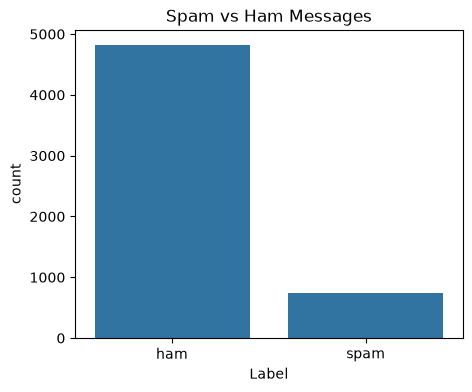

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Label")
plt.title("Spam vs Ham Messages")
plt.show()

## Text Preprocessing

### The preprocessing steps include:

- Convert text to lowercase
- Remove punctuation
- Remove stopwords
- Apply stemming to reduce words to their root form

In [33]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(stemmer.stem(word))
    return " ".join(filtered_words)


In [34]:
df["Processed_Message"] = df["Message"].apply(preprocess_text)
df.head()

,Label,Message,Processed_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is a text feature extraction technique that converts text into numerical values. It assigns higher weights to words that are important in a particular message while reducing the importance of common words that appear in many messages.

In [35]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Processed_Message"])

y = df["Label"]

## Splitting the Dataset into Training and Testing Sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4457, 8069)
Testing Shape: (1115, 8069)


## Training the Multinomial Naive Bayes Model

In [37]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

## Evaluating the Multinomial Naive Bayes Model

In [38]:
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, nb_pred, pos_label="spam"))
print("F1 Score:", f1_score(y_test, nb_pred, pos_label="spam"))

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Accuracy: 0.9614349775784753
Precision: 1.0
Recall: 0.7133333333333334
F1 Score: 0.8326848249027238

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.71      0.83       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



## Training the Logistic Regression Model

In [39]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, lr_pred, pos_label="spam"))
print("F1 Score:", f1_score(y_test, lr_pred, pos_label="spam"))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.9426008968609866
Precision: 0.9574468085106383
Recall: 0.6
F1 Score: 0.7377049180327869

Classification Report:

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       965
        spam       0.96      0.60      0.74       150

    accuracy                           0.94      1115
   macro avg       0.95      0.80      0.85      1115
weighted avg       0.94      0.94      0.94      1115



## Confusion Matrix

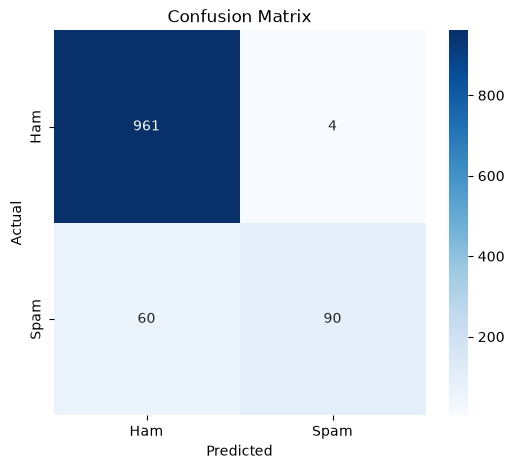

In [40]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Why is Recall Important in Spam Detection?

Recall is an important evaluation metric for spam detection because it measures how many actual spam messages are correctly identified by the model. A higher recall reduces the number of spam messages that are incorrectly classified as legitimate emails (false negatives). This helps protect users from unwanted or potentially harmful spam messages reaching their inbox.

## WordCloud Visualization

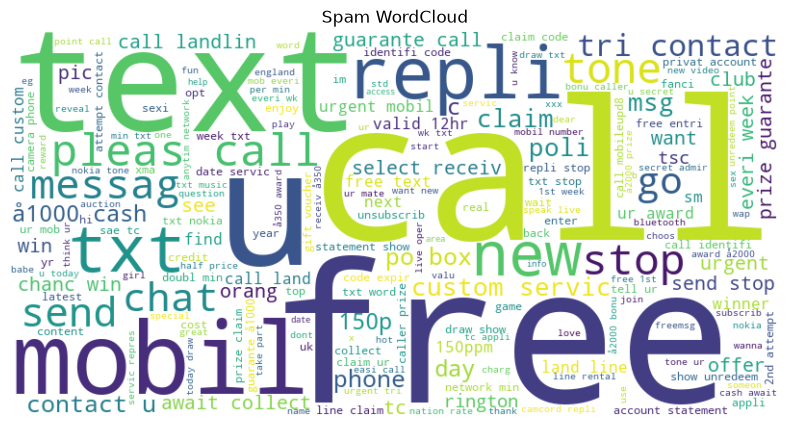

In [41]:
spam_text = " ".join(df[df["Label"] == "spam"]["Processed_Message"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()

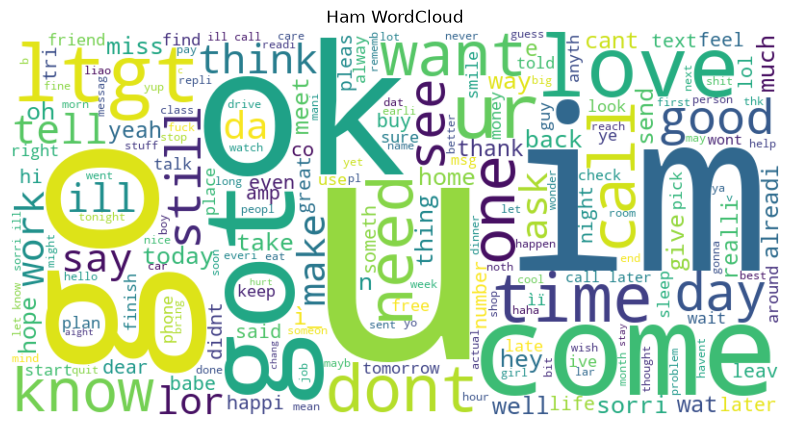

In [42]:
ham_text = " ".join(df[df["Label"] == "ham"]["Processed_Message"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

# Conclusion

In this project, an Email Spam Detection model was developed using Natural Language Processing and Machine Learning techniques. The text data was preprocessed through lowercase conversion, punctuation removal, stopword removal, and stemming. TF-IDF Vectorizer was used to transform text into numerical features. Two machine learning models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix. The results demonstrate that machine learning can effectively classify spam and legitimate messages. WordCloud visualizations also provided useful insights into the most frequent words appearing in spam and ham messages.